# Introduction to Linear Regression
---
by [Olabanji Olaniyan](https://www.linkedin.com/in/olabanji-olaniyan-59a6b0198)

In the world of generative AI and advanced machine learning models and architectures, linear regression feels like an old, wired telephone relative to the iPhone. However, Linear regression is one of the foundational and widely used supervised machine learning techniques for predicting a quantitative response.

It may not seem as fancy as Support Vector Machines, Decision Trees, or gradient boosting. Still, many of these advanced approaches can be seen as generalisations or extensions of linear regression, and this is why understanding this basic concept is essential.


In the world of generative AI and advanced machine learning models and architectures, linear regression feels like an old, wired telephone relative to the iPhone. However, Linear regression is one of the foundational and widely used supervised machine learning techniques for predicting a quantitative response.

It may not seem as fancy as Support Vector Machines, Decision Trees, or gradient boosting. Still, many of these advanced approaches can be seen as generalisations or extensions of linear regression, and this is why understanding this basic concept is essential.

## **I. What is Linear Regression?**
---
A regression task involves using a set of features (input data) to predict a quantitative response (output or target). For example, predicting someone's **salary** based on their years of experience and level of education.

We are trying to find a function $f:X->Y$ such that our target variable $Y$ is $ Y = f(X)$ 

**Key assumption**: Linear regression makes the assumption that there is an approximately linear relationship between the target variable and the features. For example, it assumes that the salary of an employee can be derived with a linear function of features such as experience and education

## **II. Classification of Linear Regression**
---
We can classify regression into two categories based on the number of features or predictors used in modelling.

1. **Simple Linear Regression**: Based on the assumption that the target variable is dependent on only one feature. Only one feature is used, and it can be approximately modeled as 

$$
Y \approx \theta_0 + \theta_1X \tag{1}
$$

For example, $salary = \theta_0 + \theta_1 experience$

2. **Multiple Linear Regression**: The limitation of simple linear regression is immediately obvious as it is unlikely in the real world that a target output will be dependent on just one feature. MLR is based on the assumption that the target variable is dependent on more than one feature. Mathematically, it can be expressed as 

$$
Y = \theta_0 + \theta_1 X_1 + \theta_2 X_2  \dots + \theta_p X_p \tag{2}
$$

For example $$salary = \theta_0 + \theta_1 experience + \theta_2 education +\theta_3 age$$

## **III. Solving Linear Regression Models**
---

As stated earlier, a crucial part of linear regression and supervised learning in General is to find a function that maps the features to the output. For Linear regression, this involves the estimation of parameters $\theta_1 \dots \theta_n$. In practice, we don't know the values of these parameters, and several approaches are taken to estimate them. 

### **A. Objective: Least Squares Method**


We aim to optimise the model parameters so that our model's predictions align closely with the actual data points in our dataset. A common way we estimate these parameters is using the `least squares method`.
To understand the least square approach, we need the residuals and the residual sum of squares RSS.

The residual is the difference between the actual value of the data point and our model's prediction. Let's assume that $\hat{y_i} = \theta _0 + \theta_1x_i$ is the prediction of the ith instance of then the residual (error) of our prediction is the difference between the actual value of $y_i$ and its prediction by the function, $\hat{y_i}$.

Hence, the residual for i is actual - predicted, mathematically expressed as $e_i = y_i - \hat{y_i}$


The objective is to calculate the residuals for all the predictions our models make, and this is called the residual sum of squares, RSS.

$$
RSS = e_1^2 + e_2^2 + \dots +e_n^2
$$

For data points 1 to n. The least-square approach chooses parameters that minimise the RSS of the data.

### **B. Solution Methods**
The objective is to find parameters of linear regression models using the least square method. Two common methods are

1. **Normal equation:** This is a closed-form solution. (This is what is implemented in `scikitlearn's Linear Regression Estimator`)
2. **Gradient descent:** Done using an iterative optimisation algorithm

**Normal equation**

The Normal Equation is a closed-form solution to find the parameters  $\theta $ that minimize the Residual Sum of Squares (RSS) in linear regression.

Given the model:

$$
y = X \theta + \epsilon
$$

where:
- $y$ is the vector of observed outputs (target variable),
- $X$  is the Feature matrix of input features (with a column of ones for the intercept ($\theta_0$)),
- $\theta$ is the vector of parameters to estimate,
- $\epsilon$ is the error term.

The objective is to minimize:

$$
RSS(\theta) = (y - X \theta)^\top (y - X \theta)
$$

The Normal Equation gives the optimal parameters as:

$$
\hat{\theta} = (X^\top X)^{-1} X^\top y
$$

This equation directly computes the parameter vector without iterative optimization.

---

**Note:**  
- The matrix $ X^\top X $ must be invertible (non-singular) $|X| \neq 0$ for the Normal Equation to work.  
- For very large datasets, computing the inverse can be computationally expensive.


## **IV. Optional Mathematical Intuition**
---
This is to build a little mathematical intuition into why Using Least sqaures is possible. The **Residual Sum of Squares (RSS)** is a **quadratic function** (i.e function of degree two) of the model parameters. As a result, it has a **convex shape** `U`, which means there is always a **unique global minimum**.

For example, consider the simple function:

$$
y = x^2
$$

Its first derivative is:

$$
\frac{dy}{dx} = 2x
$$

and its second derivative is:

$$
\frac{d^2y}{dx^2} = 2
$$

Since the second derivative is **positive**, the function is **convex**, and thus has a **minimum at** \( x = 0 \).

Similarly, the RSS function is convex in the parameters, so optimisation methods like the **normal equation** or **gradient descent** are guaranteed to find the minimum.


## **V. Code Implemntation**
---

In [1]:
# load all libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


#### **1. Convergence of A squared function e.g RSS**
---

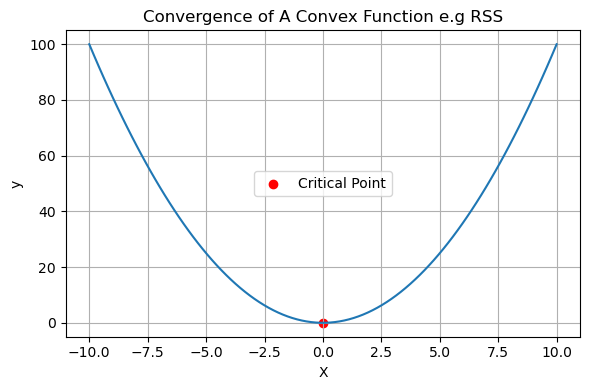

In [2]:
X = np.linspace(-10,10,100)
y = X**2
#dy/dx = 2x so when 2x = 0, critical point is when x == 0, same logic applies to all squared function
plt.figure(figsize=(6,4))
plt.plot(X,y)
plt.scatter(0,0, c= 'r', zorder = -5, label = "Critical Point")# which is the global minimum in this case
plt.grid()
plt.legend(loc = 'center')
plt.xlabel('X')
plt.ylabel('y')
plt.title("Convergence of A Convex Function e.g RSS")
plt.tight_layout()
plt.show()

### **2. Solving Least Squares using the Normal Equation**
---

In [3]:
class OLS:
    def __init__(self,X_train,y_train) -> None:
        self.X_original = X_train
        self.X_train = X_train
        self.y_train = y_train
        self.estimated_parameters = None

    # i need to firstly add the np.ones to the dataset (X)
    def prepare(self):
        bias = np.ones(self.X_original.shape[0])
        self.X_train = np.column_stack((bias, self.X_original)) # this is important to keep model from changing after every run
        return self.X_train
        
    def train(self):
        """
        Parameters
        ----------
        X_train : array-like, shape (n_samples, n_features)
            Feature matrix, where n_samples is the number of datapoints and n_features is the number of predictors/features.
        y_train : array-like, shape (n_samples,) or (n_samples, 1)
            Target output vector.
        
        Returns
        -------
        estimated_parameters : ndarray, shape (n_features,) or (n_features, 1)
            Estimated coefficients using Ordinary Least Squares.
        """
        # We use Moore-Penrose pseudoinverse to handle cases where X^TX might be singular
        # np.matmul(np.linalg.pinv(np.matmul(X.T,X)),np.matmul(X.T,y)) --> This is more explicit but verbose and might be numerically
        # unstable for edge cases.
        self.prepare() # this is already defined in the prepare method
        self.estimated_parameters = np.matmul(np.linalg.pinv(self.X_train), self.y_train)
        return self.estimated_parameters

#so to make predictions I need to matmul the estimated params by the features
    def predict (self, X_test):
        bias = np.ones(X_test.shape[0])
        X_test = np.column_stack((bias, X_test))
        self.predictions = np.matmul(X_test, self.estimated_parameters)
        return self.predictions


<!-- ### Why do we take parial derivatives and set them to zero?
---

This is because we need to find the critical points of that dunction. The way to find the critical points of a fucntion is to find the derivative of that function and set them to be zero. AT that point we have a minimum point, or maximum point or saddle point

> Least Squares is the Analytival method for solving regression while gradient descent is an iterative approach

- A critical point of a function us the point where the derivative is zero  i.e no change in y. These points can be either local maxima, or local minima. that is if we set $f'(x) = 0$ we will get $x_c$ which are called the critical points
- if we then plug in $x_c$ and $f''(x_c) > 0$ then the critical point x_c is called local minima


- if we then plug in $x_c$ and $f''(x_c) < 0$ then the critical point x_c is called local maxima

> intuition is that at that point the function changes from one sign to another

So because the RSS is a convex function if we can find the values of the cricial point those points will be our best parameters -->

## **VII. Practical Implementation of Sklearn Linear Regression Method and Our implementation**
---

We utilise a Fuel consumption dataset from the UCI Machine Learning repository to demonstrate a working implementation of the methods described above. The target variable is `mpg`. We are simply trying to predict the fuel consumption of a vehicle based on specific information about the vehicle's type and composition.

### **1. Load Dataset**
[Dataset Link](https://archive.ics.uci.edu/dataset/9/auto+mpg) 

Alternatively, run the code in this notebook.

This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for the "mpg" attribute.  The original dataset is available in the file "auto-mpg.data-original".

"The data concerns city-cycle fuel consumption in miles per gallon, to be predicted in terms of 3 multivalued discrete and 5 continuous attributes." (Quinlan, 1993)

In [4]:
# fetch dataset from uci 
auto_mpg = fetch_ucirepo(id=9) 

In [5]:
# data (as pandas dataframes) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 
  
# print some info 
print(auto_mpg.metadata['additional_info']['summary'])
  


This dataset is a slightly modified version of the dataset provided in the StatLib library.  In line with the use by Ross Quinlan (1993) in predicting the attribute "mpg", 8 of the original instances were removed because they had unknown values for the "mpg" attribute.  The original dataset is available in the file "auto-mpg.data-original".

"The data concerns city-cycle fuel consumption in miles per gallon, to be predicted in terms of 3 multivalued discrete and 5 continuous attributes." (Quinlan, 1993)


In [6]:
# variable information 
print(auto_mpg.variables) 

# data (as pandas dataframes) 
X = auto_mpg.data.features 
y = auto_mpg.data.targets 

           name     role         type demographic description units  \
0  displacement  Feature   Continuous        None        None  None   
1           mpg   Target   Continuous        None        None  None   
2     cylinders  Feature      Integer        None        None  None   
3    horsepower  Feature   Continuous        None        None  None   
4        weight  Feature   Continuous        None        None  None   
5  acceleration  Feature   Continuous        None        None  None   
6    model_year  Feature      Integer        None        None  None   
7        origin  Feature      Integer        None        None  None   
8      car_name       ID  Categorical        None        None  None   

  missing_values  
0             no  
1             no  
2             no  
3            yes  
4             no  
5             no  
6             no  
7             no  
8             no  


In [7]:
# merge data together as we will need to remove null
df = pd.concat((X,y), axis= 1)

print(f"The shape of the data is {df.shape}")
print('='*30)
print(X.info())

The shape of the data is (398, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 21.9 KB
None


In [8]:
# drop null entries
df = df.dropna()

# select X and y
X = df.drop(columns='mpg')
y = df['mpg']

# train-test-split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.4, random_state= 42)


### **2. Implementation with SKlearn**

In [9]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred1 = lin_reg.predict(X_test)


mse1 = mean_squared_error(y_test, y_pred1)
mse1

10.57049888431622

### **3. Implementation with our algorithm**

In [10]:
my_lin_reg = OLS(X_train= X_train, y_train=y_train)
my_lin_reg.train()
y_pred2 = my_lin_reg.predict(X_test=X_test)
mse2 = mean_squared_error(y_test, y_pred2)

### **4. Results**
---
The results are the same with a mean squared error of 10.57 each

In [11]:
print(f"The mean squared error of sklearn's linear reg is {mse1:.2f}")
print(f"The mean squared error of our implementation is {mse2:.2f}")



The mean squared error of sklearn's linear reg is 10.57
The mean squared error of our implementation is 10.57
